## Homework 5: Retrieval‑Augmented Generation (RAG)

### Grading and penalties

The maximum grade allowed for this assignment is __14 points__.

The assignment must be completed independently. "Similar" solutions are considered plagiarism, and all students involved (including those from whom the plagiarism was committed) cannot receive more than 0 points for it. All code must be written independently. Using someone else's code is prohibited, even with a link to the source. Within reasonable limits, of course. Taking a couple of obvious lines of code to implement a small feature is acceptable.

Ineffective code implementation may negatively impact your grade. Your grade may also be reduced for poorly readable code and poorly formatted graphs. All answers must be accompanied by the code or comments explaining how it was derived.

__Soft deadline 03.12.25 23:59__ \
__Hard deadline 07.12.25 23:59__

### About the task

In this homework assignment, you'll implement a cooking assistant using RAG. You'll need to write the entire system logic yourself, without specialized libraries. We've divided it into several components, each of which will be assigned a separate task:
1. Vector database with fast semantic search
2. Chunking
3. Document ranking
4. Generation

### About the data

We'll use user recipes from the website "Povarenok.ru" as our database. These recipes were obtained through web scraping, so some of the text may not be as clean as expected. The dataset contains 84,130 recipes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Loading the dataset and model

The recipes are stored in the file `povarenok.csv`. Each record contains the recipe name, a list of ingredients, and the recipe itself. Although the dataset contains 84,130 records in total, for this task we'll work with the first 10,000 to speed things up. You can use more if you'd like.

In [2]:
from datasets import load_dataset

dataset = load_dataset('csv', data_files=['povarenok.csv'], split='train')
dataset = dataset.select(range(10000))
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['name', 'ingredients', 'text'],
    num_rows: 10000
})

In [3]:
dataset[0]

{'name': 'Густой молочно-клубничный коктейль',
 'ingredients': "['Молоко', 'Клубника', 'Сахар']",
 'text': 'Не размораживая, ягоду положите в блендер, добавьте молоко и сахар (если ягода свежая, то и перепелиное яйцо) Взбивайте на высокой скорости до полного измельчения ягод. Вылете в стаканы и можно по чуть-чуть пить, так как этот напиток оочень холодный. Кто не любит таковой, подождите и выпейте, когда он немного согреется. Приятного аппетита!'}

Let's look at the distribution of text lengths. It's important to know what we're dealing with, since RAG assumes we'll be feeding texts into the model.

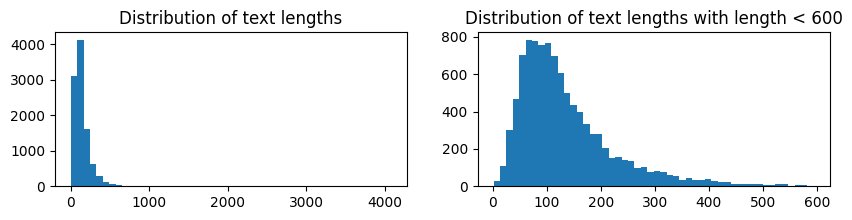

In [5]:
lens = np.array([len(dataset[i]['text'].split()) for i in range(len(dataset))])

plt.figure(figsize=(10, 2))
plt.subplot(1, 2, 1)
plt.hist(lens, bins=50)
plt.title('Distribution of text lengths')

plt.subplot(1, 2, 2)
plt.hist(lens[lens < 600], bins=50)
plt.title('Distribution of text lengths with length < 600')

plt.show()

We see that texts are often quite long. Therefore, cheating is impossible, and before vectorization, each text will need to be broken into smaller chunks to avoid overloading the model's context and to prevent losing important information when vectorizing the texts at the stage of storing them in a vector database.

Let's begin implementing RAG.

## Retrieval-Augmented Generation

Use the [`Qwen/Qwen2-1.5B-Instruct`](https://huggingface.co/Qwen/Qwen2-1.5B-Instruct) model from huggingface as a basis for the assistant. It's important to note that this is an `Instruct` model, meaning it's designed for answering the questions.

__Task 0 (0.5 points).__ Test how the model responds to cooking questions without a RAG. This is necessary to determine whether a RAG is even necessary for this task.

In [ ]:
# your code here

### Locality Sensitive Hashing (LSH)

In RAG, each query requires searching for relevant documents in the vector database. Since there are so many documents, calculating the relevance of each one will take a very long time. Therefore, it is important for us to search quickly. To achieve this, we are even willing to sacrifice some accuracy.

In this section, you will implement [Locality Sensitive Hashing](https://en.wikipedia.org/wiki/Locality-sensitive_hashing).

The idea behind LSH is quite simple. We divide all vectors from the database into groups consisting of similar vectors. At the beginning of the search, we identify a group that matches the query vector and calculate the relevance only for objects in this group. To divide the groups, we introduce several hash functions. Each of them will be constructed using the following algorithm:
1. Generate $k$ random vectors (hyperplane normal vectors).
2. For a single point (vector) in the database and a normal vector, write 1 if the point lies above the corresponding hyperplane. Otherwise, write 0.
3. Repeat the procedure for all points and normal vectors. This will produce a list of $k$ 0s and 1s for each point, which will be the hash.
4. Store the points found for each hash in a hash table.
5. Repeat steps 1-4 $L$ times and obtain $L$ different hash tables.

Now, for each new vector $q$, we can very quickly find a set of vectors similar to it. To do this, we calculate the query hash in each hash table and take all the vectors whose hash matches $q$ in at least one of them. We then re-rank the found vectors by relevance (distance to the query vector) and retain a specified number of the closest ones.

The complexity of forming hash tables can be estimated as $O(nLkd)$, where $n$ is the number of vectors in the database and $d$ is the vector's dimension. Meanwhile, the complexity of LSH search is $O(Lkd + (nLp) \cdot d)$, where $p$ is the probability that the hash of two random points will match (p tends to 0). The complexity of exhaustive search is $O(nd)$, so LSH is almost $\frac{n}{Lk}$ times faster!

__Task 1 (3 points).__ Implement a vector database with LSH search. The database should be able to add new vectors and quickly find the closest vectors to an input query. When creating the database, generate the suitable number of hash functions. Consider how to choose the number of hash tables and the number of hash functions, as well as the distribution from which to draw these random vectors. When adding a new vector to the database, calculate its hash and record the groups it belongs to.

Try to optimize the code and don't forget to test that your LSH works as intended. The easiest way to do this is to build a database of points on a two-dimensional plane. Also, compare the speed of LSH search with exhaustive search. If you've done everything correctly, you should see a search speedup of approximately 4x for 1000 points.

In [7]:
# your code here

### Chunking

Since some texts are quite long, encoding them entirely with a single vector will result in some information being lost. A vector, after all, has a limited size. To avoid losing information, we'll divide the text into chunks and encode each chunk separately.

__Task 2 (2 points).__ Implement a [recursive chunking](https://dev.to/eteimz/understanding-langchains-recursivecharactertextsplitter-2846) for a text with levels `["\n\n", "\n", " ", ""]`. Add intersections between chunks for levels `[" ", ""]`. This means that if an entire paragraph fits in a single chunk, there's no need to intersect it with anything. However, if the paragraph doesn't fit and must be divided by words (or characters), then you need to add intersections with words from adjacent chunks within the same paragraph.

Choose the values for the maximum size of each piece and the intersection length yourself.

In [ ]:
# your code here

## RAG

Finally, we can begin building the RAG system. First, let's build a vector database from recipe fragments. To obtain text embeddings, use the [`intfloat/multilingual-e5-large`](https://huggingface.co/intfloat/multilingual-e5-large`) model; it was created specifically for this task and works well with the Russian language.

__Task 3 (1.5 points).__ Build a vector database using the functions you wrote. The process shouldn't take much time on a GPU, but we recommend saving the result to disk to avoid re-vectorizing the entire dataset when restarting the kernel. Verify that your database retrieve relevant texts.

In [ ]:
# your code here

### Generation

Of all the RAG components, this is the most creative. You need to come up with a prompt that will best help the model generate a response.

__Task 4 (2 points).__ Write a function to generate a response to a text query in the RAG paradigm. Find relevant documents and assemble a prompt from them, additionally explaining to the model what is required of it. Limit the number of texts in the prompt by selecting the most relevant ones. Note that our dataset, in addition to the recipe, includes a list of ingredients and the name of the dish. Consider how you can use these. Feed the prompt to the model to generate a response. Tune the generation hyperparameters to control for variation. Remember that the model must strictly adhere to the instructions, not invent facts, and not generate anything that is not required. Demonstrate your results with 3-5 examples.

In [8]:
# your code here

__Task 6 (1 point).__ Demonstrate your final assistant's performance in various scenarios (different question topics, varying difficulty). Provide examples of both successful and unsuccessful responses. Why doesn't your system always work as expected? What are its limitations and advantages? What do you think could be done to improve it?

In [ ]:
# your code here

## Bonuses

### Web search (2 points)

As you might have noticed, the language model with RAG performs much better than without it. Despite this, it still regularly hallucinates. The quality of the RAG approach depends largely on the dataset and the model, in addition to the RAG components themselves. For example, a recipe dataset might lack certain facts about the dishes themselves, and some dishes might not even exist. In such a case, the model won't be able to answer the question correctly. Let's improve the quality of context generation by adding the ability for the system to search for information on the internet.

Modify the relevant text extraction process as follows. If the top-ranked texts are insufficiently similar (based on the threshold) to the query, replace them with texts found online for the query that are sufficiently similar. This way, the model will always receive a fixed number of highly relevant texts as input.

When searching the internet, we'll take advantage of the fact that all search engines sort results by relevance to the query. This means we can take our query, paste it into the search engine, and follow the resulting links, analyzing the text on each page until we've collected a sufficient number of relevant texts. To browse the internet, you'll need the [`requests`](https://requests.readthedocs.io/en/latest/) library, and to extract text from a page, the easiest way is to use [`BeautifulSoup`](https://www.crummy.com/software/BeautifulSoup/bs4/doc/).

Have you improved the quality of your responses?

In [ ]:
# your code here

### Dialog history (1 point)

A significant drawback of the current approach is that the assistant can't ask follow-up questions based on its own responses. The entire query must be rewritten, adding more detail. This is generally a solution, but it would be better if the system stored a history of conversations and then used it to generate new responses. This task asks you to add this functionality.

There are many ways to integrate history into the model. For example, you could simply store all questions and responses and provide them with context. However, this would significantly increase the size of the prompt, increasing the time and memory costs for each response. Of course, you could try filtering the history, leaving only those queries and responses that relate to the current query. However, this would still overload the prompt. Therefore, there is a much better approach.
Before searching for relevant texts, we'll ask the model to reformulate the received query so that it is more complete and includes the context of previous communication. For example, "What is the calorie content of this?" -> "What are the calories in a Caesar salad?" With this new query, we can search for relevant texts based on history without increasing the final prompt size.

Implement the described scheme. To reformulate the query, use the same model as for generation, and make sure it performs well. What challenges did you encounter?

In [ ]:
# your code here

## Self-Query (1 point)

We aks you to read about the [SelfQuery](https://medium.com/%40danushidk507/rag-x-self-query-retriever-952dd55c68ed) method and implement it. Briefly, we use a model to preprocess the query and extract some metadata from it, which we can use to filter the dataset. For example, in the query "I want something sweet with strawberries, but no mango," we'll extract the products "strawberry" and "mango," then filter the database based on the products, and find "something sweet" in the resulting subset.

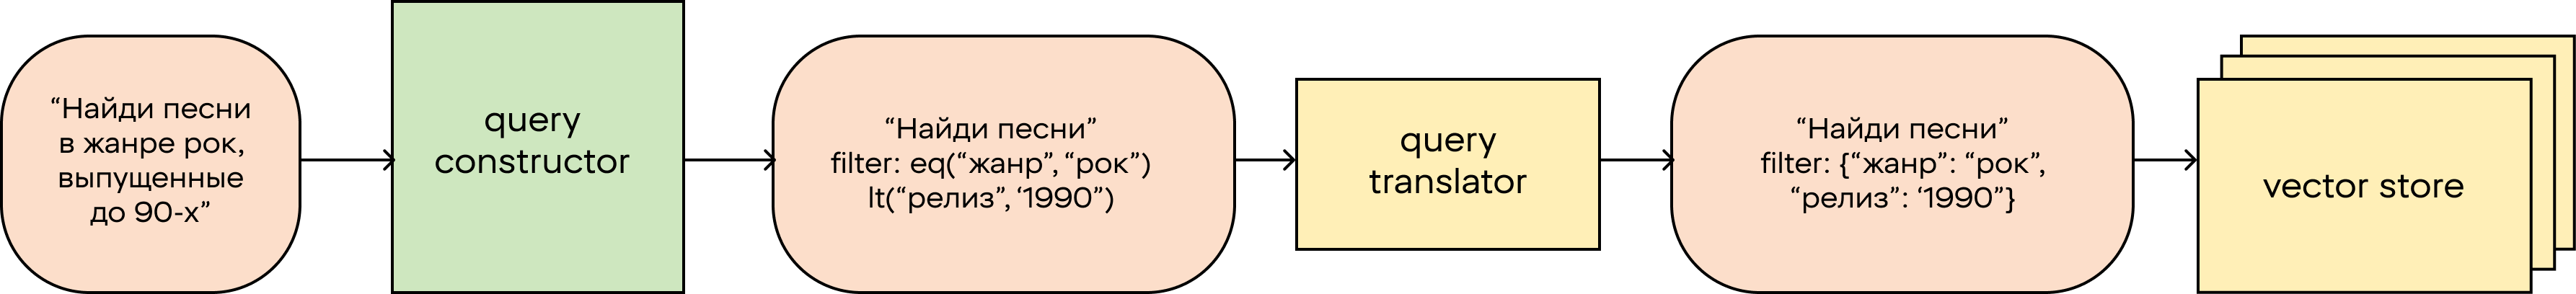

To extract metadata, you can use either JSON generation in a specific format or SGR.

[Schema-Guided Reasoning (SGR)](https://abdullin.com/schema-guided-reasoning/) is a method that encourages large language models (LLMs) to produce structured, understandable, and predictable answers by forcing them to reason through predefined steps. By creating a special schema (or structured template), you explicitly specify:

* which steps the model must go through (prevents skipping or loss of logic),
* the order in which the reasoning chain must occur (ensures coherence),
* what specific elements should be addressed (increases depth and precision).

Instead of freely generating text—often inconsistent or ambiguous—the schema acts as a rigid guide. This structure is then enforced on the model using constrained decoding (structured output).

In [ ]:
# your code here